<a href="https://colab.research.google.com/github/cafrancog/Analitica_De_Negocios/blob/main/Reto_parcial_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Reto parcial 2
* Analítica de Negocios
* 12 de Mayo de 2025
* Carlos Andrés Franco


1. Paquetes y librerías

In [136]:
# Modelo neuronal
!pip install tensorflow

import tensorflow as tf


# Manipulación de datos
import numpy as np
import pandas as pd

#Gráficas
import seaborn as sns
import matplotlib.pyplot as plt

# Base de datos
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Obtener datos

In [137]:
bdatos = pd.read_excel("/content/drive/MyDrive/Drive documents/Eafit/Septimo semestre/ANEG/S16/Parcial 2/7. BGD and Cost of Debt - Feb 2023_Int.xlsx")

display(bdatos.head())

esg = bdatos.iloc[1:,9]
esg.head()

e = bdatos.iloc[1:,15]
e.head()

s = bdatos.iloc[1:,21]
s.head()

g = bdatos.iloc[1:,27]
g.head()

bgdp = bdatos.iloc[1:,51]
bgdp.head()


bs = bdatos.iloc[1:,63]
bs.head()

fb = bdatos.iloc[1:,69]
fb.head()

ibm = bdatos.iloc[1:,81]
ibm.head()

emgd = bdatos.iloc[1:,87]
emgd.head()

waccc = bdatos.iloc[1:,33]
waccc.head()

waccl = bdatos.iloc[1:,39]
waccl.head()

datos = pd.concat([esg, e, s, g, bgdp, bs, fb,
                   ibm, emgd, waccc, waccl], axis=1)
datos.columns = ['esg', 'e', 's', 'g', 'bgdp', 'bs', 'fb',
                 'ibm', 'emgd', 'waccc', 'waccl']

datos.head()


print(datos.isnull().sum())

#se encuentran pocos NA, se procede a removerlos

datos = datos.dropna()

print(datos.isnull().sum())

#Se confirma eliminación de los NA, ahora se procede con normalidad



,Identifier (RIC),Company Name,Country of Headquarters,TRBC Economic Sector Name,ESG Score\nIn the last 6 FY,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 90,Unnamed: 91,Unnamed: 92,Unnamed: 93,SDG 5 Gender Equality\nIn the last 6 FY,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99
0,NaN,NaN,NaN,NaN,2017.000000,2018.000000,2019.000000,2020.000000,2021.000000,2022.000000,...,2019.000000,2020.000000,2021.000000,2022.000000,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0
1,FBP.N,First Bancorp,Puerto Rico,Financials,NaN,NaN,NaN,26.158077,27.480724,47.373394,...,NaN,70.000000,70.000000,80.000000,NaN,NaN,NaN,NaN,0.0,0.0
2,ENGEPEC1.LM,Enel Generacion Peru SAA,Peru,Utilities,NaN,32.955725,31.531678,31.073299,67.905779,64.897646,...,13.793103,13.235294,47.058824,42.647059,NaN,NaN,NaN,NaN,0.0,1.0
3,LUSURC1.LM,Luz del Sur SAA,Peru,Utilities,16.265296,15.190708,13.121411,10.818837,8.076124,11.404420,...,52.941176,54.411765,55.882353,58.571429,NaN,NaN,NaN,0.0,0.0,0.0
4,INVCENC1.LM,Inversiones Centenario SAA,Peru,Consumer Cyclicals,13.706108,13.243963,26.228234,32.274557,35.191335,42.611203,...,75.000000,72.058824,67.647059,71.428571,NaN,NaN,NaN,0.0,0.0,1.0


esg      0
e        0
s        0
g        0
bgdp     2
bs       1
fb       2
ibm      8
emgd     3
waccc    0
waccl    0
dtype: int64
esg      0
e        0
s        0
g        0
bgdp     0
bs       0
fb       0
ibm      0
emgd     0
waccc    0
waccl    0
dtype: int64


In [138]:
entrada = np.array(datos[['esg', 'e', 's', 'g', 'bgdp', 'bs', 'fb',
                 'ibm', 'emgd']])

salida1 = np.array(datos[['waccc']])
salida2 = np.array(datos[['waccl']])

print(entrada)
print(salida1)
print(salida2)

XDo=[59.29,16.17,83.88,42.66,72.01,6,16.67,3.36,26.87]
pronosticar = np.array(XDo)

[[47.37339441  3.17671395 44.42731372 ... 20.         90.
  25.        ]
 [64.89764563 57.13100048 85.08304405 ... 14.28571429 61.76470588
  14.28571429]
 [11.4044201   1.591586   16.93455798 ...  0.          7.14285714
  16.66666667]
 ...
 [13.9152861  22.51502543  8.79853059 ...  0.         70.45454545
   0.        ]
 [33.90035725 17.59558824 25.10461359 ...  0.         50.
   0.        ]
 [29.04942447 38.42444842 25.79650301 ...  7.69230769 16.10169492
   0.        ]]
[[0.02733849]
 [0.02048165]
 [0.04181841]
 [0.03154971]
 [0.02337997]
 [0.02305201]
 [0.04141849]
 [0.02135195]
 [0.03420735]
 [0.04251938]
 [0.02764473]
 [0.01826642]
 [0.02639729]
 [0.01459909]
 [0.01298096]
 [0.0178477 ]
 [0.02275091]
 [0.02214519]
 [0.02202695]
 [0.02426952]
 [0.02567814]
 [0.02672819]
 [0.02425108]
 [0.01809356]
 [0.03018563]
 [0.01751577]
 [0.03743814]
 [0.03202774]
 [0.01881788]
 [0.02478559]
 [0.02315922]
 [0.0296248 ]
 [0.02295859]
 [0.01950092]
 [0.0304245 ]
 [0.0172894 ]
 [0.0236446 ]
 [0.03

Normalizar los datos

In [139]:
n_entrada = entrada/np.max(entrada, axis=0)
n_salida1 = salida1
n_salida2 = salida2
n_pronosticar = pronosticar/np.max(entrada, axis=0)

print("entrada n", n_entrada.min(), n_entrada.max())
print("pronosticar n", n_pronosticar.min(), n_pronosticar.max())


entrada n 0.0 1.0
pronosticar n 0.033765517241379314 0.869374462977336


Implementación modelo MADALINE Sigmoid para WACC corto plazo "waccc"

In [140]:
madaline_sigc = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=(9,),
                          activation = "relu",
                          use_bias = False),
    tf.keras.layers.Dense(1, activation = "sigmoid",
                          use_bias = False)])
madaline_sigc.summary()
madaline_sigc.load_weights("/content/drive/MyDrive/Drive documents/Eafit/Septimo semestre/ANEG/S16/Parcial 2/7. pesos_sigmoid_WACCS.weights.h5")
madaline_sigc.compile(optimizer = "sgd", loss = "mse")
history = madaline_sigc.fit(n_entrada,
                  n_salida1,
                  epochs = 250)

predicción_waccc = madaline_sigc.predict(n_entrada)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (400.00 B)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0591  
Epoch 2/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0566 
Epoch 3/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0539 
Epoch 4/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0509
Epoch 5/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0477
Epoch 6/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0454
Epoch 7/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0424
Epoch 8/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0404
Epoch 9/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0390
Epoch 10/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0344
Epoch 11/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0335
Epoch 12/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0322
Epoch 13/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0313
Epoch 14/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0291
Epoch 15/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss:

Evaluar MADALINE_SIGC

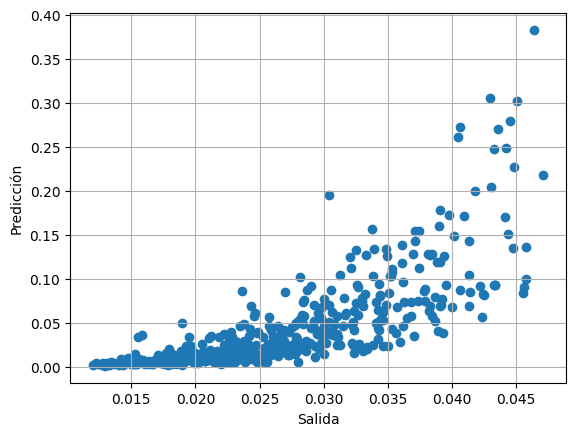

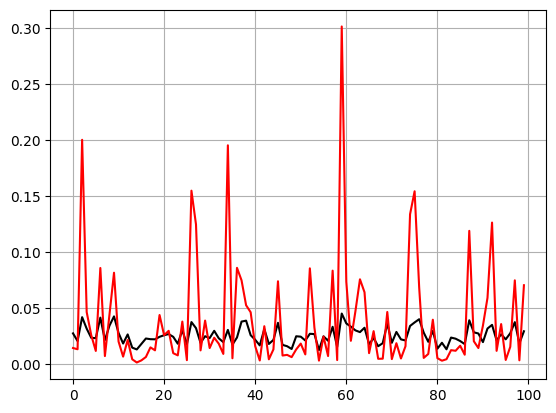

In [141]:
plt.figure()
plt.scatter(n_salida1, predicción_waccc)
plt.xlabel("Salida")
plt.ylabel("Predicción")
plt.grid()
plt.show()


plt.figure()
plt.plot(n_salida1[0:100], color = "black")
plt.plot(predicción_waccc[0:100], color = "red")
plt.grid()
plt.show()



In [142]:
corr_madaline_sigc = pd.DataFrame(np.column_stack((n_salida1,
                                             predicción_waccc)))
print("La correlación de los datos es:\n", corr_madaline_sigc.corr())


print("el coeficiente de correlación es de",
      np.corrcoef(n_salida1.flatten(),predicción_waccc.flatten()))

La correlación de los datos es:
           0         1
0  1.000000  0.758299
1  0.758299  1.000000
el coeficiente de correlación es de [[1.         0.75829888]
 [0.75829888 1.        ]]


Peso de cada variable en WACCC

In [143]:
wc1 = madaline_sigc.get_weights()
w1 = wc1[0]
c1 = wc1[1]
a1 = w1@c1

pesos_waccc = pd.DataFrame(a1,
                           columns = ['Efecto'],
                           index = ['esg', 'e', 's', 'g', 'bgdp', 'bs', 'fb', 'ibm', 'emgd'])

display(pesos_waccc)

,Efecto
esg,-1.771288
e,-1.249825
s,0.536782
g,-0.881323
bgdp,-1.163655
bs,-0.996092
fb,0.384113
ibm,-1.834702
emgd,-1.008144


Pronosticar una nueva empresa con WACCC

In [144]:

pronostico_waccc = madaline_sigc.predict(n_pronosticar.reshape(1, -1))
print("El pronóstico de es:", pronostico_waccc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
El pronóstico de es: [[0.0488008]]


MADALINE Sigmoid WACC largo plazo

In [145]:
madaline_sigl = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=(9,),
                          activation = "relu",
                          use_bias = False),
    tf.keras.layers.Dense(1, activation = "sigmoid",
                          use_bias = False)])
madaline_sigl.summary()
madaline_sigl.load_weights("/content/drive/MyDrive/Drive documents/Eafit/Septimo semestre/ANEG/S16/Parcial 2/7. pesos_sigmoid_WACCL.weights.h5")
madaline_sigl.compile(optimizer = "sgd", loss = "mse")
history = madaline_sigl.fit(n_entrada,
                  n_salida2,
                  epochs = 250)

predicción_waccl = madaline_sigl.predict(n_entrada)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (400.00 B)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2418  
Epoch 2/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2200 
Epoch 3/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2033 
Epoch 4/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1866 
Epoch 5/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1726 
Epoch 6/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1578 
Epoch 7/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1465 
Epoch 8/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1345 
Epoch 9/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1252 
Epoch 10/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1118 
Epoch 11/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1076 
Epoch 12/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0980 
Epoch 13/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0905 
Epoch 14/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0837 
Epoch 15/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

Evaluar MADALINE Sigmoid WACCL

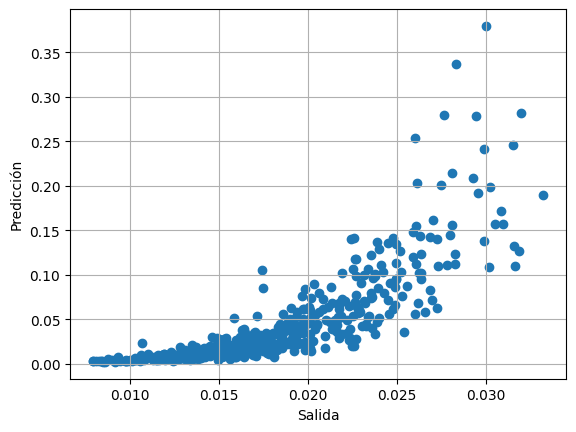

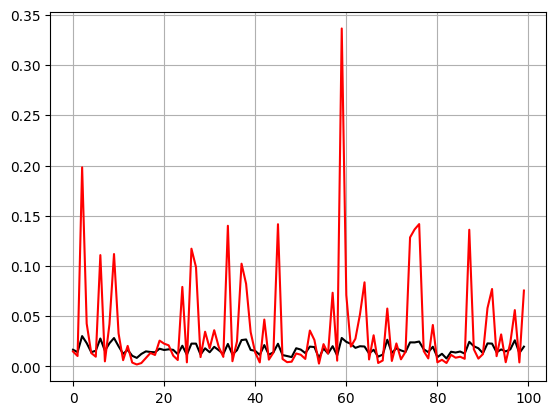

In [146]:
plt.figure()
plt.scatter(n_salida2, predicción_waccl)
plt.xlabel("Salida")
plt.ylabel("Predicción")
plt.grid()
plt.show()


plt.figure()
plt.plot(n_salida2[0:100], color = "black")
plt.plot(predicción_waccl[0:100], color = "red")
plt.grid()
plt.show()


In [147]:
corr_madaline_sigl = pd.DataFrame(np.column_stack((n_salida2,
                                             predicción_waccl)))
print("La correlación de los datos es:\n", corr_madaline_sigl.corr())


print("el coeficiente de correlación es de",
      np.corrcoef(n_salida2.flatten(),predicción_waccl.flatten()))

La correlación de los datos es:
         0       1
0  1.0000  0.8051
1  0.8051  1.0000
el coeficiente de correlación es de [[1.         0.80509982]
 [0.80509982 1.        ]]


Pesos WACCL

In [148]:
wc2 = madaline_sigl.get_weights()
w2 = wc2[0]
c2 = wc2[1]
a2 = w2@c2

pesos_waccl = pd.DataFrame(a2,
                           columns = ['Efecto'],
                           index = ['esg', 'e', 's', 'g', 'bgdp', 'bs', 'fb', 'ibm', 'emgd'])

display(pesos_waccl)

,Efecto
esg,-1.418370
e,-0.655101
s,-1.463209
g,-0.479058
bgdp,-0.886263
bs,-1.813918
fb,-0.845641
ibm,-0.862949
emgd,-0.404314


Pronosticar el WACCL de una nueva empresa

In [149]:
pronostico_waccl = madaline_sigl.predict(n_pronosticar.reshape(1, -1))
print("El pronóstico de es:", pronostico_waccl)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
El pronóstico de es: [[0.01887675]]


Modelo Autoencoder

In [150]:
datos_n = datos/np.max(datos, axis=0)

madaline_a = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=(11,),
                          activation = "relu",
                          use_bias = False),
    tf.keras.layers.Dense(11, activation = "relu",
                          use_bias = False)])
madaline_a.summary()
madaline_a.load_weights("/content/drive/MyDrive/Drive documents/Eafit/Septimo semestre/ANEG/S16/Parcial 2/7. pesos_autoencoder_BGD.weights.h5")
madaline_a.compile(optimizer = "sgd", loss = "mse")
history2 = madaline_a.fit(datos_n,
                  datos_n,
                  epochs = 250)

predicción_a = madaline_a.predict(datos_n)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 11)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220 (880.00 B)

 Trainable params: 220 (880.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1156  
Epoch 2/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1170 
Epoch 3/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1103
Epoch 4/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1098 
Epoch 5/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1064 
Epoch 6/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1083 
Epoch 7/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1040 
Epoch 8/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1012 
Epoch 9/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0986 
Epoch 10/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1046 
Epoch 11/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0985 
Epoch 12/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0966 
Epoch 13/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0994 
Epoch 14/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0968 
Epoch 15/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - los

In [151]:
correlaciones = pd.DataFrame((np.column_stack((datos_n, datos_n)))).corr()
nombres_columnas = ['esg', 'e', 's', 'g', 'bgdp', 'bs', 'fb', 'ibm',
                    'emgd', 'waccc', 'waccl', 'esg_pred', 'e_pred',
                    's_pred', 'g_pred', 'bgdp_pred', 'bs_pred', 'fb_pred',
                    'ibm_pred', 'emgd_pred', 'waccc_pred', 'waccl_pred']
correlaciones.columns = nombres_columnas
correlaciones.index = nombres_columnas
correlaciones.rows = nombres_columnas
display(correlaciones)



correlaciones.to_excel("correlaciones.xlsx")

<ipython-input-151-4505806ed835>:8: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  correlaciones.rows = nombres_columnas


,esg,e,s,g,bgdp,bs,fb,ibm,emgd,waccc,...,e_pred,s_pred,g_pred,bgdp_pred,bs_pred,fb_pred,ibm_pred,emgd_pred,waccc_pred,waccl_pred
esg,1.000000,0.865252,0.933199,0.721510,0.227576,0.192116,0.239127,0.243866,0.099588,-0.866102,...,0.865252,0.933199,0.721510,0.227576,0.192116,0.239127,0.243866,0.099588,-0.866102,-0.845810
e,0.865252,1.000000,0.769897,0.452743,0.161468,0.134202,0.178258,0.105278,-0.018112,-0.744787,...,1.000000,0.769897,0.452743,0.161468,0.134202,0.178258,0.105278,-0.018112,-0.744787,-0.729045
s,0.933199,0.769897,1.000000,0.525690,0.161608,0.143671,0.192739,0.170403,0.078836,-0.775464,...,0.769897,1.000000,0.525690,0.161608,0.143671,0.192739,0.170403,0.078836,-0.775464,-0.755649
g,0.721510,0.452743,0.525690,1.000000,0.305587,0.202592,0.283736,0.408611,0.213496,-0.725266,...,0.452743,0.525690,1.000000,0.305587,0.202592,0.283736,0.408611,0.213496,-0.725266,-0.711208
bgdp,0.227576,0.161468,0.161608,0.305587,1.000000,0.101946,0.924034,0.119278,0.104500,-0.649203,...,0.161468,0.161608,0.305587,1.000000,0.101946,0.924034,0.119278,0.104500,-0.649203,-0.637034
bs,0.192116,0.134202,0.143671,0.202592,0.101946,1.000000,-0.023052,0.041681,-0.017030,-0.173022,...,0.134202,0.143671,0.202592,0.101946,1.000000,-0.023052,0.041681,-0.017030,-0.173022,-0.174879
fb,0.239127,0.178258,0.192739,0.283736,0.924034,-0.023052,1.000000,0.106631,0.153617,-0.640478,...,0.178258,0.192739,0.283736,0.924034,-0.023052,1.000000,0.106631,0.153617,-0.640478,-0.628369
ibm,0.243866,0.105278,0.170403,0.408611,0.119278,0.041681,0.106631,1.000000,0.042298,-0.215338,...,0.105278,0.170403,0.408611,0.119278,0.041681,0.106631,1.000000,0.042298,-0.215338,-0.211076
emgd,0.099588,-0.018112,0.078836,0.213496,0.104500,-0.017030,0.153617,0.042298,1.000000,-0.227799,...,-0.018112,0.078836,0.213496,0.104500,-0.017030,0.153617,0.042298,1.000000,-0.227799,-0.242433
waccc,-0.866102,-0.744787,-0.775464,-0.725266,-0.649203,-0.173022,-0.640478,-0.215338,-0.227799,1.000000,...,-0.744787,-0.775464,-0.725266,-0.649203,-0.173022,-0.640478,-0.215338,-0.227799,1.000000,0.980156


#**Análisis general**

Variables

El presente trabajo con el objetivo de buscar si la equidad de género en organizaciones explica un menor costo de capital WACC a corto y largo plazo, ha sido realizado según los lineamientos empleando 9 variables de entrada, y 2 de salida, a continuación se explicará cada una.

'esg', 'e', 's', 'g', 'bgdp', 'bs', 'fb',
                 'ibm', 'emgd', 'waccc', 'waccl

* "esg" ESG Score es la puntuación que tiene la empresa respecto a la sostenibilidad ambiental (E), social (S), y de gobernanza (g), esta es medida con una puntuación que va de 0 a 100, por lo tanto esta consolida las siguientes cuentas "e", "s" y "g".

* "e" este es el pilar ambiental del ESG que muestra que tan responsable es la compañía frente a su impacto al medio ambiente.

* "s" el pilar social mide la responsabilidad que tiene la compañía frente a sus stakeholders o grupos de interes, como sus empleados, proveedores, clientes, accionistas y poblaciones afectadas por sus actividades

* "g" es el pilar de gobernanza, esta mide la responsabilidad que se tiene en el liderazgo de la empresa, algunos ejemplos incluyen: si hay un marco claro para tomar las decisiones, transparencia, relacionamiento de la gerencia con la compañía (si tienen acciones, es una empresa familiar, etc..) y equidad de género ( ejemplo: participación de mujeres suele llevar a decisiones mas conservadoras que hagan contrapeso a las decisiones usualmente mas impulsivas de los hombres, además de contar con ideas diferentes)


* "bgdp" Board Gender Diversity, Score o diversidad de género en la junta directiva, muestra el porcentaje de mujeres presentes en el consejo directivo, este va de 0% a 100%, esta cuenta es probablemente calculada con la información de "bs" y "fb".


* "bs" board size o tamaño de la junta directiva muestra la cantidad de miembros presentes en esta, son números enteros, por ejemplo 7, 8, 9 y tiene que ser mayor a 0, pero no cuenta con un límite superior.

* "fb" female on board o mujeres en la junta directiva, incluye el conteo de personas de género femenino que se encuentran en la junta directiva de una compañía, estos son números enteros con un mínimo de 0 y un máximo indefinido.

* "ibm" Independent Board Members o miembros independientes del consejo directivo, es la cantidad de miembros independientes en el consejo directivo frente a los miembros totales, esto da un porcentaje que puede ir desde 0%.

* "emgd" o "egd" en el documento fuente, significa Executive Members Gender Diversity, este es el porcentaje de mujeres que se encuentran en cargos ejecutivos frente a la planta ejecutiva total de la compañía

* "waccc" es el costo de capital de la empresa a corto plazo (menor a 1 año), esto puede incluir deuda a corto plazo, emisión de bonos, y el costo de oportunidad de los accionistas, este es un porcentaje que usualmente es mayor a 0 y menor a 1.

* "waccl" o WACC largo plazo, funciona igual que el WACC a corto plazo, pero tiene en cuenta solo el costo de capital a plazos mayores de un año.

Hallazgos

Al observar las correlaciones reales de las variables, se encuentra como ambos WACC no cuentan con correlaciones positivas, las cuales en el caso de waccc van desde -0.1730 con bs hasta -0.8661 con esg, que todos los elementos de tengan correlaciones negativas, demuestra que a aumento de cualquiera de estos, el costo de capital a corto plazo de la compañía debería disminuir.

A continuación, en el marco del waccl se encuentran correlaciones casi identicas, desde -0.1748 con bs, hasta -0.8458 con esg. esto explicado por la gran correlación entre ambos wacc (0.9801)

Ahora en el marco de los pesos de los modelos MADALINE Sigmoid, waccl presenta similaridad con sus correlaciones, ya que todas estas cuentan con pesos negativos, aquí se encuentra que el mayor motor reductor de WACCL es "s" (sostenibilidad social), la cual tiene coherencia con la hipótesis de la equidad, dado a que una mayor equidad de género, se reflejaría en el cálculo de esta cuenta, aunque no solo la equidad de la junta directiva, sinó la de todos los grupos de interés, esta cuenta tiene un peso de -1.46, seguida por esg con -1.41. Mientras que las cuentas con menor impacto son emgd con -0.4043 y g con -0.47.

waccc presenta una situación de pesos algo diferente, con esg siendo la primera cuenta con -1.7712 seguida por "e" con -1.2498. Además se presentan un par de cuentas menores que no cumplen con la lógica real vista en la matriz de correlaciones, tanto s y fb cuentan con pesos positivos de 0.5367 y 0.3841 respectivamente.

Estos pesos demuestran un posible márgen de mejora, en caso de ser posible acercarlos a la realidad.

Al evaluar los modelos, waccc presentó una fuerte correlación de 0.7582 frente a su base de datos, y gráficas cercanas a su objetivo, lo que muestran cierto grado de fiabilidad.

Por otro lado, waccl logra una correlación de 0.8050 y gráficas mucho mas cercanas a su objetivo, lo que demuestra que este modelo es bastante mas fiel que el realizado para waccc, aunque aun hay presente bastante márgen de mejora.

finalmente, al pronosticar una compañía nueva, el modelo waccc encuentra un costo de capital a corto plazo de 0.04880 o 4.8%, una cifra algo reducida para lo que es el contexto latinoamericano, pero posible en 2022 cuando las tasas de interés aun se encontraban bajas.

WACCL pronostica un wacc de 0.01887 o 1.8%, esta cifra sería muy improbable incluso durante pandemia que fué cuando las tasas de interés se encontraban en mínimos históricos.

En conclusión, el aumento de todas las variables de entrada utilizadas son beneficiosas para la reducción del costo de capital, sea este a corto o largo plazo en casi la misma proporción, ambos modelos tienen una fiabilidad buena para pronosticar WACC, siendo WACCL ligeramente mejor que WACCC, pero los resultados de pronóstico son algo extraños, por lo que se recomendaría revisar la causa antes de dar aprobación total a este modelo.